# **Edward Moswane Assignment 11: Image Classification Using Random Forest**

# Dataset Selection and Preprocessing

In [76]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import zipfile

from PIL import Image
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,
    recall_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

print("Libraries imported successfully!")

Libraries imported successfully!


In [77]:
#laod the zip file
from google.colab import files

uploaded = files.upload()

Saving images.zip to images.zip


In [78]:
zip_path = "/content/images.zip"
extract_path = "/content/images"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Images extracted successfully!")

Images extracted successfully!


In [79]:
# The path to the image classes
data_dir = "/content/images/images"

# Defining the five image classes
classes = ["dalmatian","dollar_bill","pizza","soccer_ball","sunflower"]

# Checking if each class folder exists
print("Dataset classes:\n")

for class_name in classes:
    folder_path = os.path.join(data_dir, class_name)

    if os.path.exists(folder_path):
        image_count = len(os.listdir(folder_path))
        print(f"✓ {class_name}: {image_count} files")
    else:
        print(f"✗ {class_name}: folder not found")

Dataset classes:

✓ dalmatian: 67 files
✓ dollar_bill: 51 files
✓ pizza: 52 files
✓ soccer_ball: 54 files
✓ sunflower: 85 files


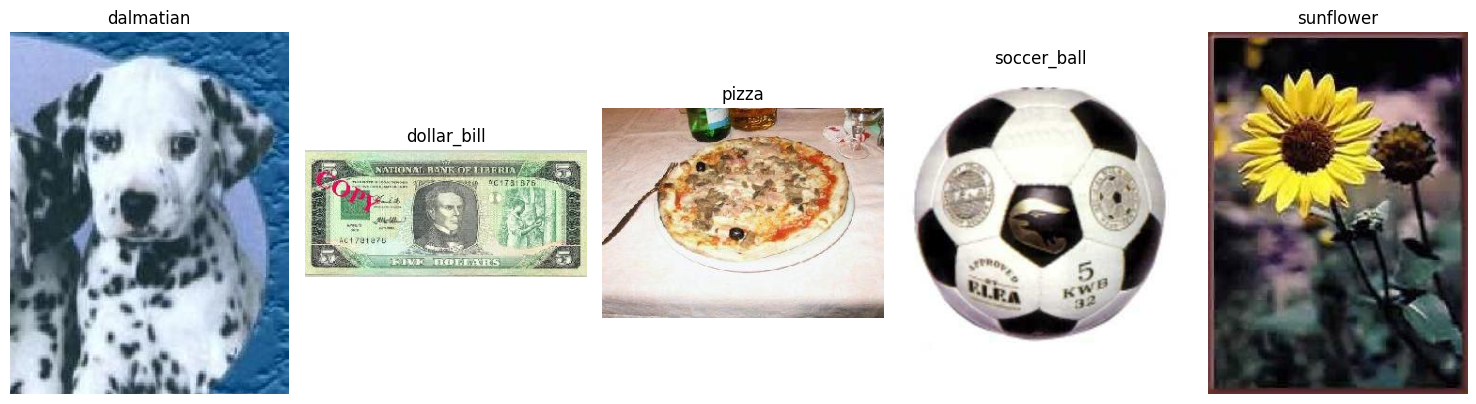

In [80]:
# Display one sample image from each class
plt.figure(figsize=(15, 4))

for i, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif"))]

    # Load the first images
    image_path = os.path.join(class_path, image_files[0])
    image = Image.open(image_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Loading and Preprocess the Images

In [81]:
# Image size for the model
IMG_SIZE = (32, 32)

X = []
y = []

# Loading images from each class folder
for label, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name)

    for file_name in os.listdir(class_path):

        # Only process image files
        if file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif")):

            image_path = os.path.join(class_path, file_name)

            try:
                # Open image and convert to RGB and resize
                image = Image.open(image_path).convert("RGB")
                image = image.resize(IMG_SIZE)

                # Converting image to NumPy array
                image_array = np.array(image)

                # Normalize pixel values from 0-255 to 0-1
                image_array = image_array / 255.0

                X.append(image_array)
                y.append(label)

            except Exception as e:
                print(f"Could not load {image_path}: {e}")

# Converting the lists to NumPy arrays
X = np.array(X)
y = np.array(y)

In [82]:
#show shapes
print("Images loaded successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Images loaded successfully!
X shape: (309, 32, 32, 3)
y shape: (309,)


Flatten Images for Random Forest

In [83]:
X_flat = X.reshape(X.shape[0], -1)

print("Original image shape:", X.shape)
print("Flattened data shape:", X_flat.shape)
print("Number of features per image:", X_flat.shape[1])

Original image shape: (309, 32, 32, 3)
Flattened data shape: (309, 3072)
Number of features per image: 3072


Splitting the dataset into training and testing sets.

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X_flat,y,
    test_size=0.20,
    random_state=42,
    stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 247
Testing samples: 62


# Model Training

Random Forest with GridSearchCV

In [85]:
# Creating the Random Forest classifier
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1)

# Defining the parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]}

# Creating GridSearchCV
grid_search = GridSearchCV(estimator=rf,param_grid=param_grid,cv=3,scoring="accuracy",n_jobs=-1,verbose=1)

# Perform grid search
grid_search.fit(X_train, y_train)

# show the best parameters
print("\nBest Parameters:")
print(grid_search.best_params_)

# Get the best Random Forest model
best_rf = grid_search.best_estimator_

print("\nBest Random Forest model:")
print(best_rf)

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Random Forest model:
RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)


# Model Evaluation:

In [109]:
# Make predictions and evaluate the Random Forest model

# Making predictions on the test set
y_pred = best_rf.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

# Display results
print("_______Random Forest Evaluation Results_______")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

_______Random Forest Evaluation Results_______
Accuracy : 0.7258
Precision: 0.7255
Recall   : 0.7258
F1-Score : 0.7221


Classification Report

In [111]:
print("______________Classification Report_______________")

print(classification_report(y_test,y_pred,target_names=classes))

______________Classification Report_______________
              precision    recall  f1-score   support

   dalmatian       0.69      0.64      0.67        14
 dollar_bill       0.67      0.80      0.73        10
       pizza       0.75      0.60      0.67        10
 soccer_ball       0.70      0.64      0.67        11
   sunflower       0.79      0.88      0.83        17

    accuracy                           0.73        62
   macro avg       0.72      0.71      0.71        62
weighted avg       0.73      0.73      0.72        62



Confusion Matrix

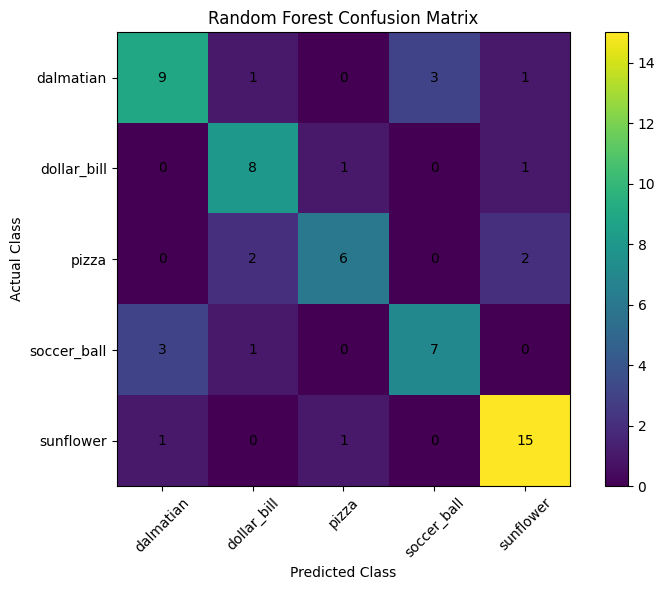

In [88]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

# Add numbers to the cells
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

Model Performance Chart

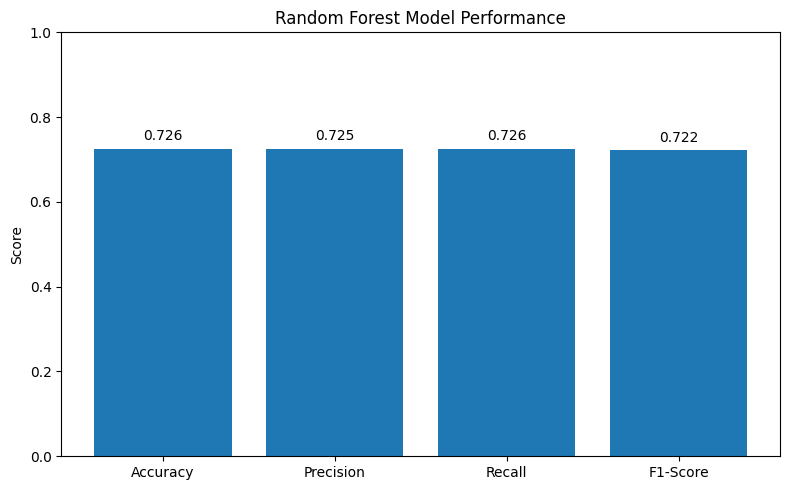

In [89]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Random Forest Model Performance")

# show values above bars
for i, value in enumerate(values):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

In [90]:
best_rf.feature_importances_

array([3.84208561e-05, 0.00000000e+00, 1.73377779e-04, ...,
       0.00000000e+00, 1.28383673e-04, 2.42764765e-04])

Make Predictions

In [112]:
# Making predictions on the test data
y_pred = best_rf.predict(X_test)

# Calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

# show results
print("___________Random Forest Evaluation Results_____________")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

___________Random Forest Evaluation Results_____________
Accuracy : 0.7258
Precision: 0.7255
Recall   : 0.7258
F1-Score : 0.7221


Classification Report

In [113]:
print("__________Random Forest Classification Report__________")

print(classification_report(y_test,y_pred,target_names=classes,zero_division=0))

__________Random Forest Classification Report__________
              precision    recall  f1-score   support

   dalmatian       0.69      0.64      0.67        14
 dollar_bill       0.67      0.80      0.73        10
       pizza       0.75      0.60      0.67        10
 soccer_ball       0.70      0.64      0.67        11
   sunflower       0.79      0.88      0.83        17

    accuracy                           0.73        62
   macro avg       0.72      0.71      0.71        62
weighted avg       0.73      0.73      0.72        62



Confusion Matrix

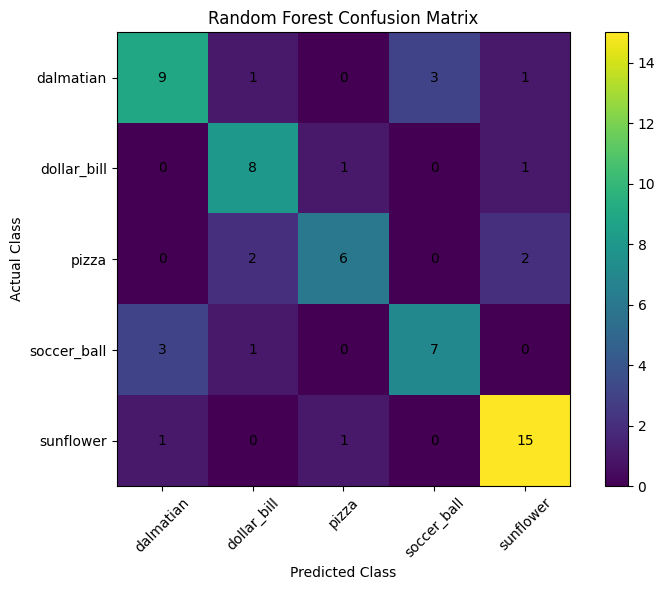

In [93]:
# Step 11: Create and visualize the confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

# Add values inside the matrix
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

Model Performance Chart

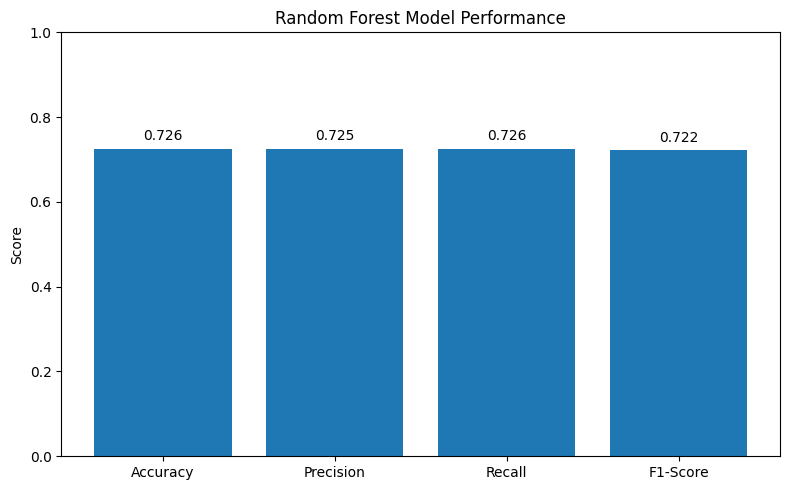

In [94]:
#Visualize Random Forest performance

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Random Forest Model Performance")

for i, value in enumerate(values):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

# Feature Importance Visualization

In [95]:
# Feature Importance

feature_importances = best_rf.feature_importances_

print("Number of features:", len(feature_importances))
print("Feature importance values obtained successfully.")

Number of features: 3072
Feature importance values obtained successfully.


Visualize of the important features

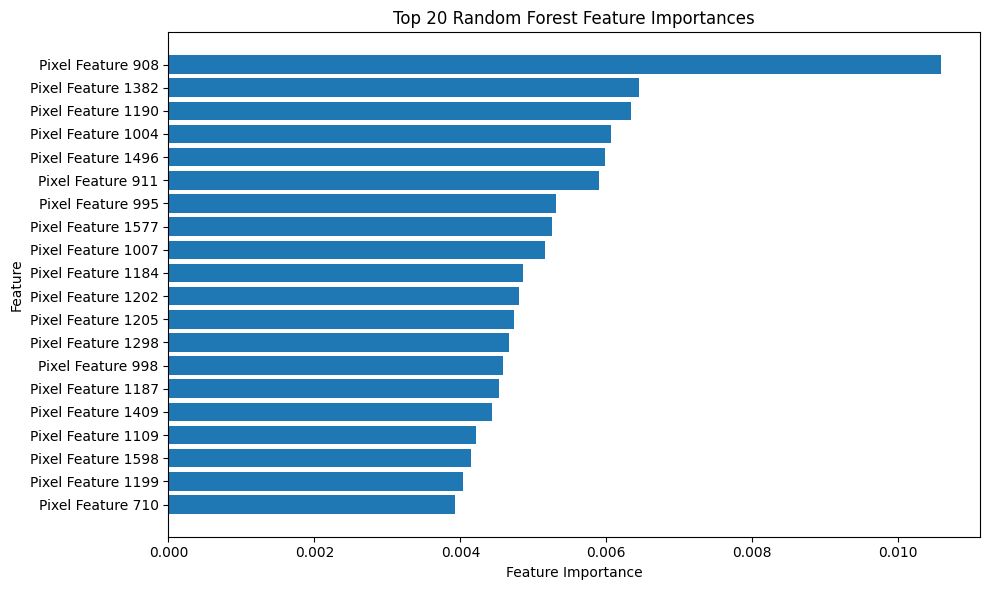

In [96]:
# Get indices of the 20 most important features
top_n = 20
top_indices = np.argsort(feature_importances)[-top_n:]

top_importances = feature_importances[top_indices]

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), top_importances)
plt.yticks(
    range(top_n),
    [f"Pixel Feature {i}" for i in top_indices])

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

# Prediction on New Images

In [97]:
# Function to predict a new image

def predict_image(image_path, model, classes):
    """
    Predict the class of a new image using the trained Random Forest model.
    """
    # Open the image
    image = Image.open(image_path).convert("RGB")

    # Resize to the same size used during training
    image = image.resize(IMG_SIZE)

    # Converting to NumPy array
    image_array = np.array(image)

    # Normalize pixel values
    image_array = image_array / 255.0

    # Flatten the image
    image_flat = image_array.reshape(1, -1)

    # Making prediction
    prediction = model.predict(image_flat)[0]

    # Convert numerical prediction to class name
    predicted_class = classes[prediction]

    return predicted_class

Test the function with a new image and print the predicted class.

In [101]:
# Finding the correct classified unseen pizza image

# Image paths recreation in the same order used when loading X
image_paths = []

for class_name in classes:
    class_path = os.path.join(data_dir, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".gif")):
            image_paths.append(
                os.path.join(class_path, file_name))

# Split the paths using the train/test split used before
paths_train, paths_test, y_paths_train, y_paths_test = train_test_split(
    image_paths,y,test_size=0.20,random_state=42,stratify=y)

# Find an unseen pizza image that the model correctly predicts
correct_pizza_path = None

for path, true_label in zip(paths_test, y_paths_test):

    if classes[true_label] == "pizza":

        prediction = predict_image(path,best_rf,classes)

        if prediction == "pizza":
            correct_pizza_path = path
            break

# Show result
if correct_pizza_path is not None:

    print("Correctly classified unseen pizza image:")
    print(correct_pizza_path)
    print("Actual class: pizza")
    print("Predicted class:",
          predict_image(correct_pizza_path, best_rf, classes))

else:
    print("No correctly classified pizza image was found in the test set.")

Correctly classified unseen pizza image:
/content/images/images/pizza/image_0017.jpg
Actual class: pizza
Predicted class: pizza


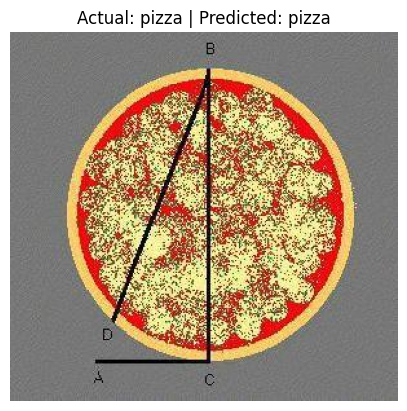

In [102]:
# show the correctly classified unseen image

if correct_pizza_path is not None:

    image = Image.open(correct_pizza_path)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title("Actual: pizza | Predicted: pizza")
    plt.axis("off")
    plt.show()

Saving image_0013.jpg to image_0013 (2).jpg
New image: image_0013 (2).jpg
Predicted class: pizza


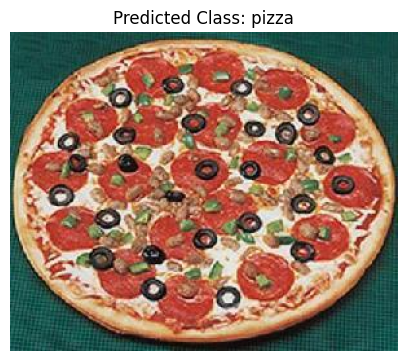

In [104]:
# Predicting a truly new image uploaded by the user

from google.colab import files

uploaded_new = files.upload()

for file_name in uploaded_new.keys():

    new_image_path = "/content/" + file_name
    prediction = predict_image(new_image_path,best_rf,classes)

    print("New image:", file_name)
    print("Predicted class:", prediction)

    # show new image
    image = Image.open(new_image_path)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(f"Predicted Class: {prediction}")
    plt.axis("off")
    plt.show()

Bonus: Comparing with SVM:

In [105]:
# Creating the SVM model
svm_model = SVC(kernel="rbf",C=10,gamma="scale")

# Training the SVM
svm_model.fit(X_train, y_train)

print("SVM training completed successfully!")

SVM training completed successfully!


Evaluate SVM model

In [114]:
# Making predictions
svm_pred = svm_model.predict(X_test)

# Calculate metrics
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(
    y_test, svm_pred, average="weighted", zero_division=0)
svm_recall = recall_score(
    y_test, svm_pred, average="weighted", zero_division=0)
svm_f1 = f1_score(
    y_test, svm_pred, average="weighted", zero_division=0)

print("_________SVM Evaluation Results________")
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-Score : {svm_f1:.4f}")

_________SVM Evaluation Results________
Accuracy : 0.8065
Precision: 0.8206
Recall   : 0.8065
F1-Score : 0.8057


Compare the results of Random Forest and SVM models.

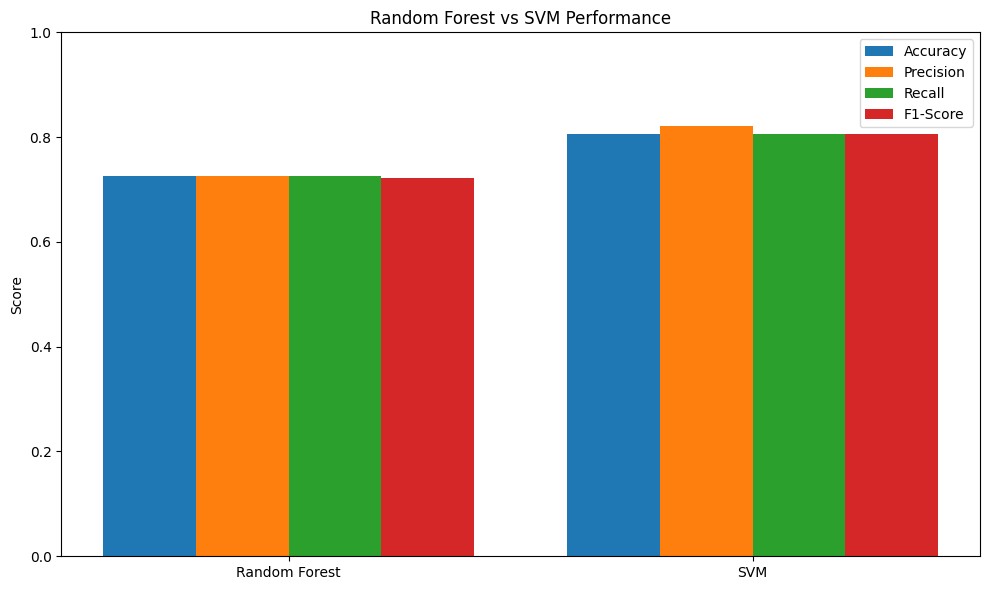

In [107]:
comparison = {
    "Accuracy": [accuracy, svm_accuracy],
    "Precision": [precision, svm_precision],
    "Recall": [recall, svm_recall],
    "F1-Score": [f1, svm_f1]}

models = ["Random Forest", "SVM"]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5 * width, comparison["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5 * width, comparison["Precision"], width, label="Precision")
plt.bar(x + 0.5 * width, comparison["Recall"], width, label="Recall")
plt.bar(x + 1.5 * width, comparison["F1-Score"], width, label="F1-Score")

plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Random Forest vs SVM Performance")
plt.legend()

plt.tight_layout()
plt.show()

Create a Results Table

In [115]:
# Creating a model comparison table

print("__________Model Performance Comparison__________")
print(f"{'Metric':<12} {'Random Forest':<18} {'SVM':<18}")
print("-" * 48)
print(f"{'Accuracy':<12} {accuracy:<18.4f} {svm_accuracy:<18.4f}")
print(f"{'Precision':<12} {precision:<18.4f} {svm_precision:<18.4f}")
print(f"{'Recall':<12} {recall:<18.4f} {svm_recall:<18.4f}")
print(f"{'F1-Score':<12} {f1:<18.4f} {svm_f1:<18.4f}")

__________Model Performance Comparison__________
Metric       Random Forest      SVM               
------------------------------------------------
Accuracy     0.7258             0.8065            
Precision    0.7255             0.8206            
Recall       0.7258             0.8065            
F1-Score     0.7221             0.8057            


**Summary of Findings**

The Random Forest model achieved 0.7258 accuracy, with similar precision, recall, and F1-score. The confusion matrix shows that the model classified sunflower images well. The SVM model performed better, achieving 0.8065 accuracy and an F1-score of 0.8057. In conclusion the results show that SVM was more effective at prediction than Random Forest for this image classification dataset.

Colab Link

https://colab.research.google.com/drive/1dhfxuyuBWp69BlytyFhURM5--chx1OR1?usp=sharing